# Experimentación y Análisis Pregunta 2 — Difusión anisotrópica, Variación Total y diseño del coeficiente de difusión 

## Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import scipy.ndimage
import skimage.data
from src.p2 import (
  rmse, coef_TV, coef_gradiente, 
    coef_laplaciano, difusion_anisotropica, 
    gradientes_4_direc, magnitud_gradiente_cuadrado, laplaciano_discreto
)

import os
os.makedirs('results', exist_ok=True)
os.makedirs(os.path.join('results', 'p2'), exist_ok=True)

## Generación datos ruido gaussiano

RMSE inicial: 0.0490


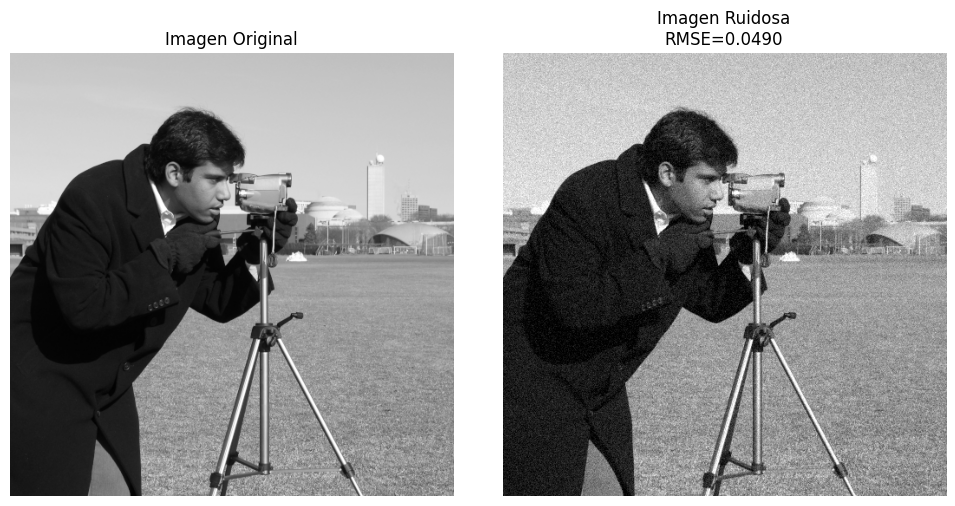

In [2]:
np.random.seed(2714)
x_clean = skimage.data.camera().astype(np.float64) / 255.0
sigma_noise = 0.05
y_noisy = np.clip(x_clean + np.random.normal(0, sigma_noise, x_clean.shape), 0, 1)

print(f"RMSE inicial: {rmse(x_clean, y_noisy):.4f}")
# grafico de la imagen original y la imagen ruidosa
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(x_clean, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Imagen Original"); axes[0].axis('off')
axes[1].imshow(y_noisy, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f"Imagen Ruidosa\nRMSE={rmse(x_clean, y_noisy):.4f}"); axes[1].axis('off')
plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'imagen_original_ruidosa.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Exploración parametro $\varepsilon$ en Variación Total

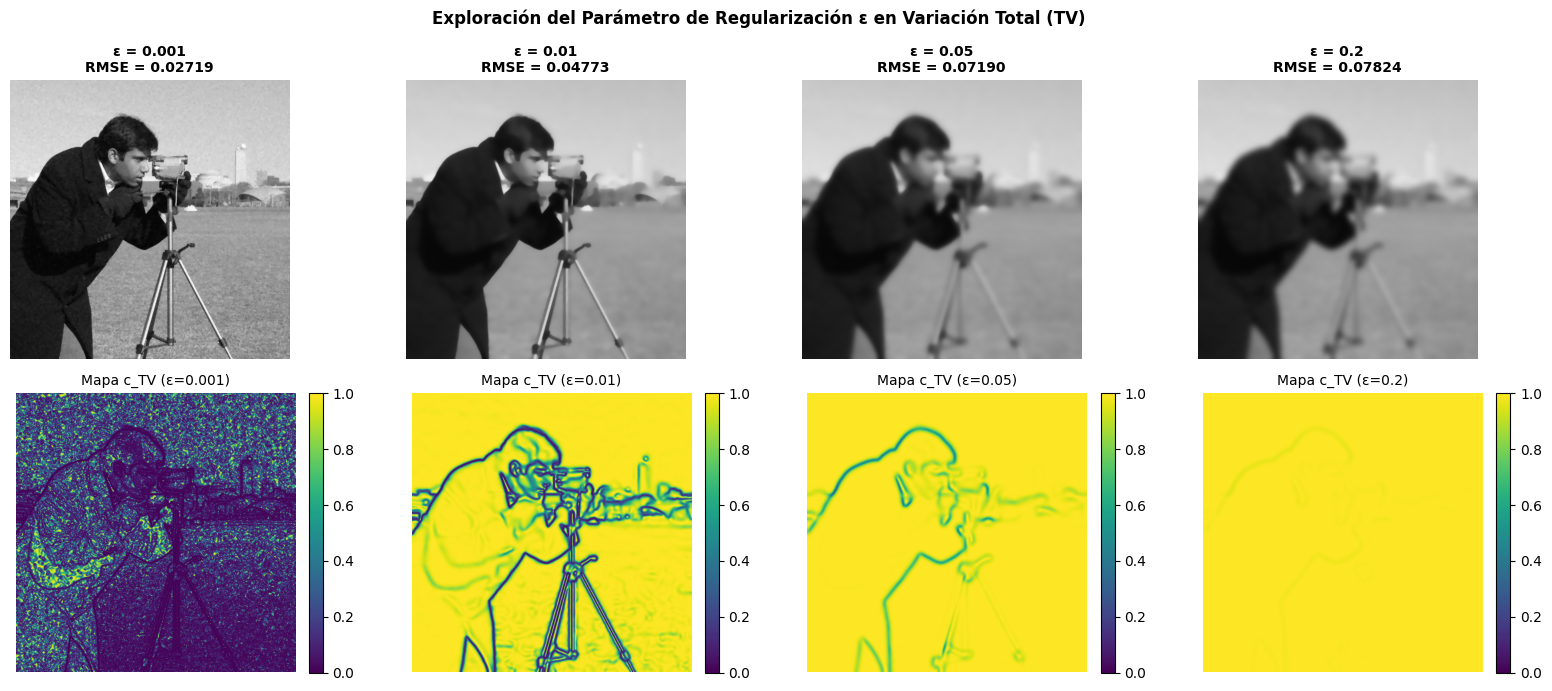

In [3]:
epsilons = [0.001, 0.01, 0.05, 0.20]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, eps in enumerate(epsilons):
    u_tv, c_tv = difusion_anisotropica(y_noisy, coef_TV, n_iter=80, dt=0.20, eps=eps)
    err = rmse(x_clean, u_tv)
    
    axes[0, i].imshow(u_tv, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"\u03b5 = {eps}\nRMSE = {err:.5f}", fontsize=10, fontweight='bold')
    axes[0, i].axis('off')
    
    im_c = axes[1, i].imshow(c_tv, cmap='viridis', vmin=0, vmax=1)
    axes[1, i].set_title(f"Mapa c_TV (\u03b5={eps})", fontsize=10)
    axes[1, i].axis('off')
    fig.colorbar(im_c, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.suptitle("Exploración del Parámetro de Regularización \u03b5 en Variación Total (TV)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'TV_barrido_epsilon.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()


## Estudio efecto conjunto de $\varepsilon$, $\lambda$ y numero de iteraciones

dt       | n_iter   | t_acumulado  | RMSE Final  
0.02     | 80       | 1.60         | 0.02720     
0.10     | 80       | 8.00         | 0.03893     
0.20     | 80       | 16.00        | 0.04773     
0.20     | 160      | 32.00        | 0.05998     


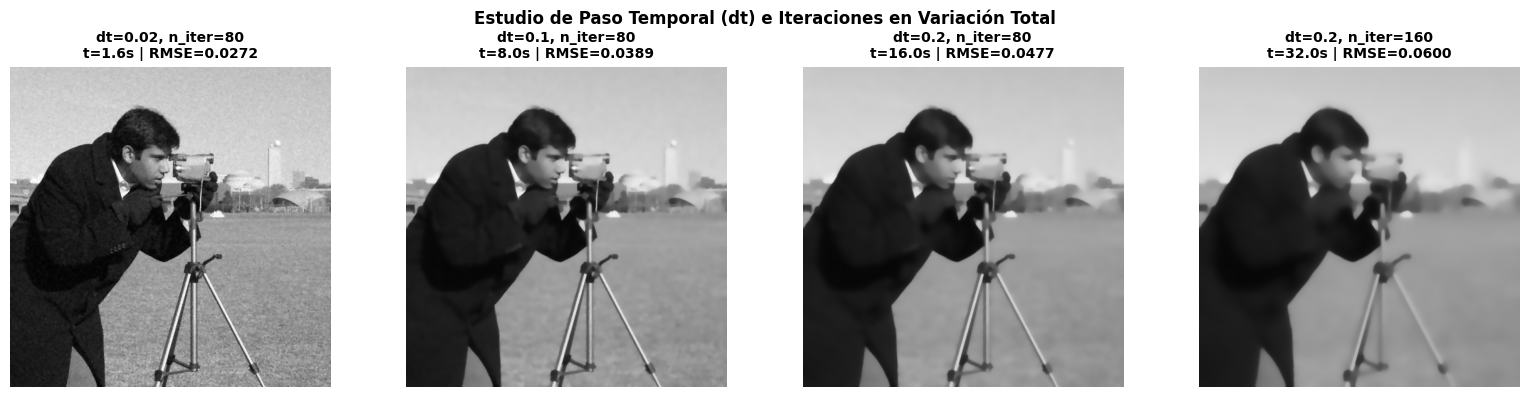

In [16]:
# Configuraciones de prueba para estudiar (dt, n_iter) sobre TV (eps=0.01)
configuraciones = [
    (0.02, 80),   # Evolución lenta (t_total = 1.6)
    (0.10, 80),   # Evolución intermedia (t_total = 8.0)
    (0.20, 80),   # Configuración de referencia (t_total = 16.0)
    (0.20, 160)   # Evolución prolongada: posible sobrealisado (t_total = 32.0)
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

print("="*50)
print(f"{'dt':<8} | {'n_iter':<8} | {'t_acumulado':<12} | {'RMSE Final':<12}")
print("="*50)

for i, (dt_val, n_it) in enumerate(configuraciones):
    u_res, c_res = difusion_anisotropica(y_noisy, coef_TV, n_iter=n_it, dt=dt_val, eps=0.01)
    err = rmse(x_clean, u_res)
    t_tot = dt_val * n_it
        
    print(f"{dt_val:<8.2f} | {n_it:<8d} | {t_tot:<12.2f} | {err:<12.5f}")
    
    axes[i].imshow(u_res, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"dt={dt_val}, n_iter={n_it}\nt={t_tot:.1f}s | RMSE={err:.4f}", fontsize=10, fontweight='bold')
    axes[i].axis('off')

print("="*50)
plt.suptitle("Estudio de Paso Temporal (dt) e Iteraciones en Variación Total", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'TV_barrido_dt_niter.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Exploración de parametros propuesta 1

K (Umbral)   | alpha (Pendiente)  | RMSE Resultante
0.02         | 1.0                | 0.05557        
0.05         | 1.0                | 0.06707        
0.10         | 1.0                | 0.07253        
0.02         | 2.0                | 0.03938        
0.05         | 2.0                | 0.05693        
0.10         | 2.0                | 0.07246        
0.02         | 4.0                | 0.03264        
0.05         | 4.0                | 0.04412        
0.10         | 4.0                | 0.06378        


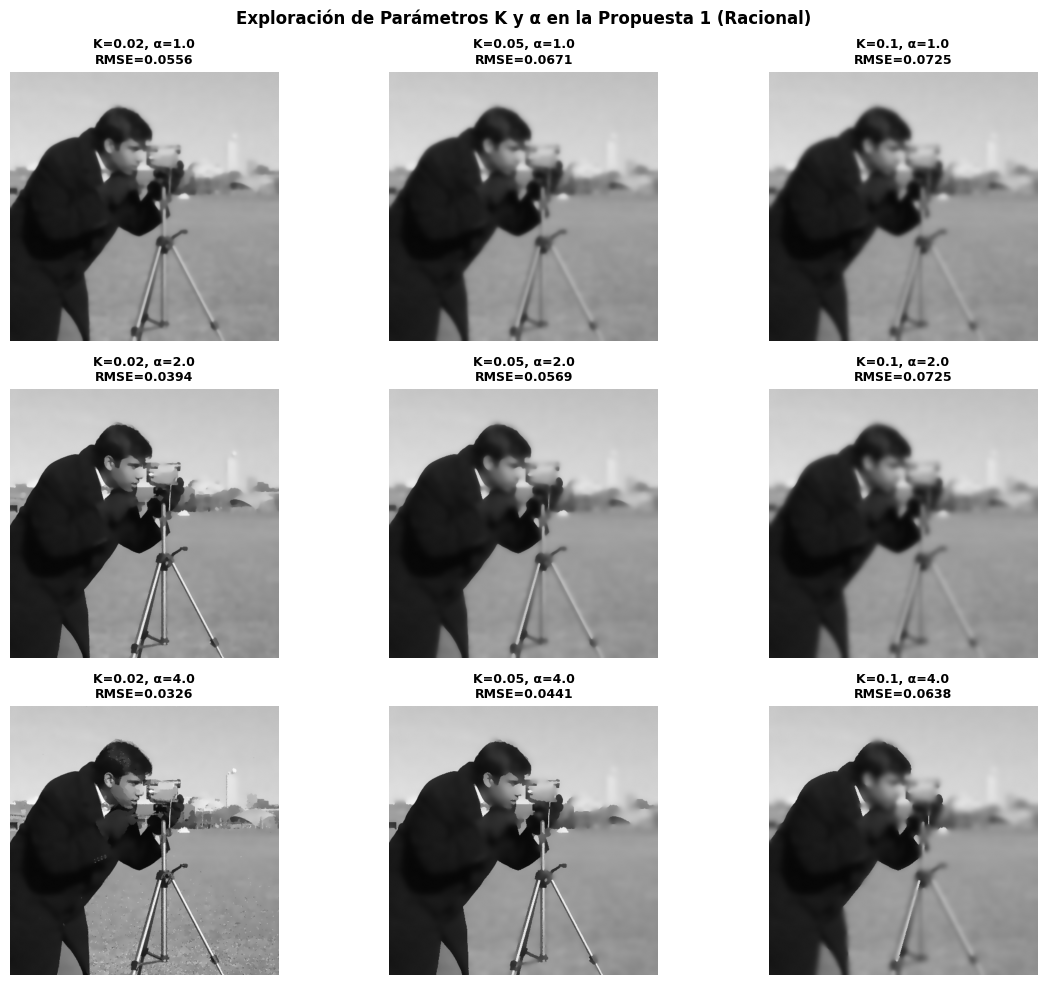

In [5]:
valores_K = [0.02, 0.05, 0.10]
valores_alpha = [1.0, 2.0, 4.0]

fig, axes = plt.subplots(len(valores_alpha), len(valores_K), figsize=(12, 10))

print("="*65)
print(f"{'K (Umbral)':<12} | {'alpha (Pendiente)':<18} | {'RMSE Resultante':<15}")
print("="*65)

for r, alpha_val in enumerate(valores_alpha):
    for c, K_val in enumerate(valores_K):
        u_p1, c_p1 = difusion_anisotropica(
            y_noisy, coef_gradiente, n_iter=80, dt=0.20, K=K_val, alpha=alpha_val
        )
        err = rmse(x_clean, u_p1)
        
        print(f"{K_val:<12.2f} | {alpha_val:<18.1f} | {err:<15.5f}")
        
        ax = axes[r, c]
        ax.imshow(u_p1, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"K={K_val}, \u03b1={alpha_val}\nRMSE={err:.4f}", fontsize=9, fontweight='bold')
        ax.axis('off')

print("="*65)
plt.suptitle("Exploración de Parámetros K y \u03b1 en la Propuesta 1 (Racional)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'P1_barrido_K_alpha.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Sensibilidad del explorador de ruido en propuesta 2 (laplaciano)

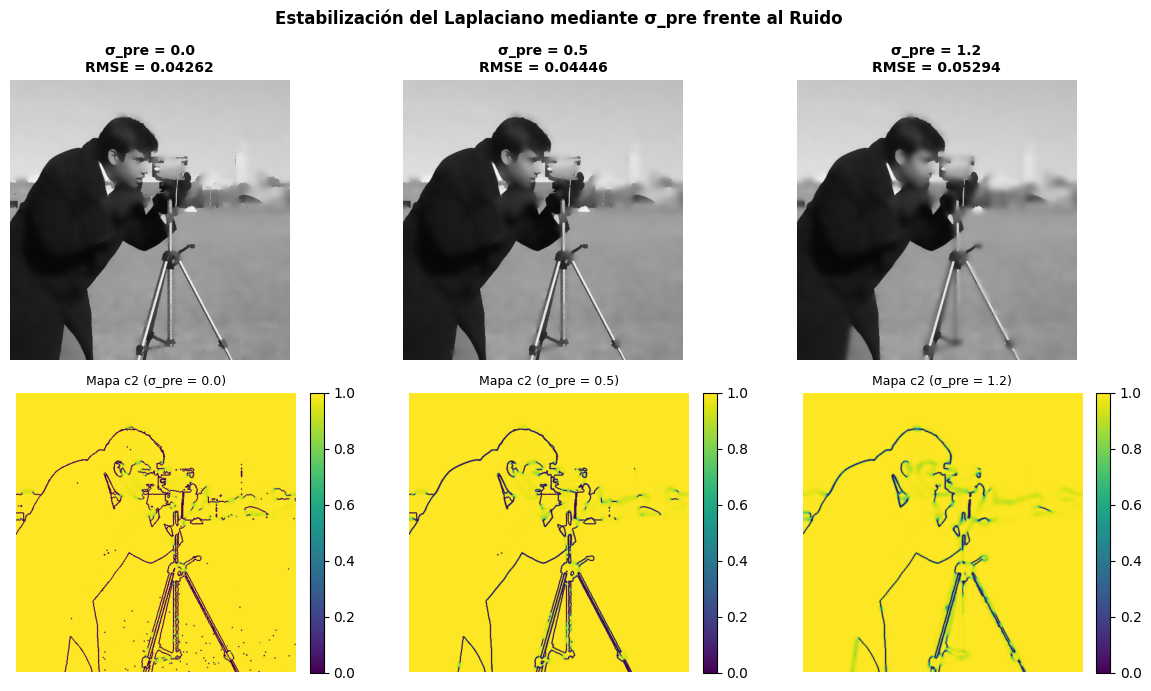

In [6]:
# PARTE 1: Efecto del Pre-suavizado sigma_pre en la Estabilización del Laplaciano
sigmas_pre_test = [0.0, 0.5, 1.2]
fig_p1, axes_p1 = plt.subplots(2, 3, figsize=(12, 7))

for idx, s_pre in enumerate(sigmas_pre_test):
    u_lap, c_lap = difusion_anisotropica(
        y_noisy, coef_laplaciano, n_iter=80, dt=0.20, 
        K_g=0.05, K_l=0.10, gamma=0.5, sigma_pre=s_pre
    )
    err = rmse(x_clean, u_lap)
    
    # Fila superior: Imagen filtrada
    axes_p1[0, idx].imshow(u_lap, cmap='gray', vmin=0, vmax=1)
    axes_p1[0, idx].set_title(f"\u03c3_pre = {s_pre}\nRMSE = {err:.5f}", fontsize=10, fontweight='bold')
    axes_p1[0, idx].axis('off')
    
    # Fila inferior: Mapa de coeficientes c2(x,y)
    im = axes_p1[1, idx].imshow(c_lap, cmap='viridis', vmin=0, vmax=1)
    axes_p1[1, idx].set_title(f"Mapa c2 (\u03c3_pre = {s_pre})", fontsize=9)
    axes_p1[1, idx].axis('off')
    fig_p1.colorbar(im, ax=axes_p1[1, idx], fraction=0.046, pad=0.04)

plt.suptitle("Estabilización del Laplaciano mediante \u03c3_pre frente al Ruido", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'laplaciano_sigmapre.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()




σ_ruido    | RMSE TV         | RMSE Prop. 1 (Grad)  | RMSE Prop. 2 (Lap)  
0.02       | 0.04745         | 0.05668              | 0.04409             
0.05       | 0.04777         | 0.05704              | 0.04436             
0.10       | 0.04889         | 0.05802              | 0.04598             


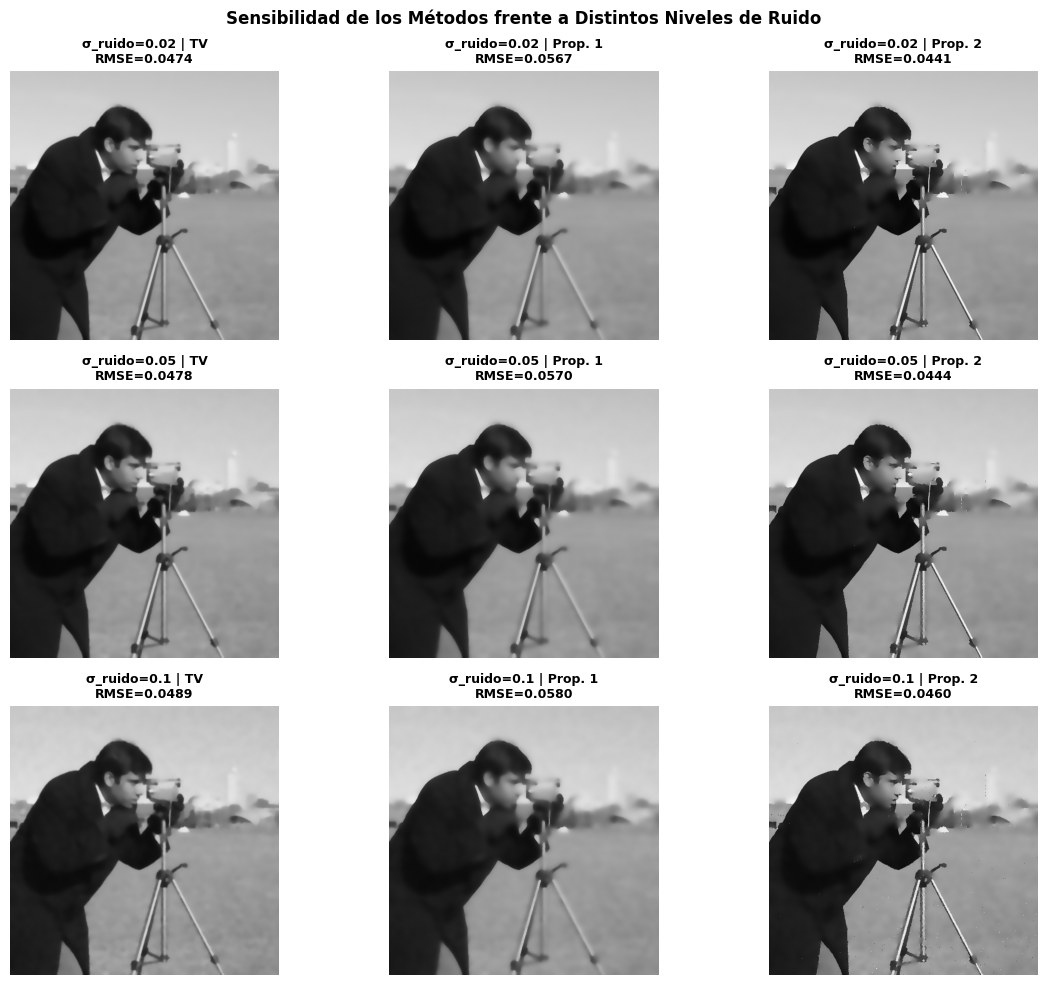

In [7]:
# PARTE 2: Sensibilidad al Ruido Comparativa (ruido sigma en [0.02, 0.05, 0.10])
niveles_ruido = [0.02, 0.05, 0.10]
fig_p2, axes_p2 = plt.subplots(len(niveles_ruido), 3, figsize=(12, 10))

print("\n" + "="*70)
print(f"{'\u03c3_ruido':<10} | {'RMSE TV':<15} | {'RMSE Prop. 1 (Grad)':<20} | {'RMSE Prop. 2 (Lap)':<20}")
print("="*70)

for r, s_noise in enumerate(niveles_ruido):
    # Generar ruido reproducible con semilla fija por nivel
    np.random.seed(2714 + int(s_noise * 100))
    y_test = np.clip(x_clean + np.random.normal(0, s_noise, x_clean.shape), 0, 1)
    
    # Filtrar con los tres métodos manteniendo la misma imagen ruidosa
    u_tv_n, _ = difusion_anisotropica(y_test, coef_TV, n_iter=80, dt=0.20, eps=0.01)
    u_p1_n, _ = difusion_anisotropica(y_test, coef_gradiente, n_iter=80, dt=0.20, K=0.05, alpha=2.0)
    u_p2_n, _ = difusion_anisotropica(y_test, coef_laplaciano, n_iter=80, dt=0.20, K_g=0.05, K_l=0.10, gamma=0.5, sigma_pre=0.5)
    
    err_tv = rmse(x_clean, u_tv_n)
    err_p1 = rmse(x_clean, u_p1_n)
    err_p2 = rmse(x_clean, u_p2_n)
    
    print(f"{s_noise:<10.2f} | {err_tv:<15.5f} | {err_p1:<20.5f} | {err_p2:<20.5f}")
    
    # Fila r
    axes_p2[r, 0].imshow(u_tv_n, cmap='gray', vmin=0, vmax=1)
    axes_p2[r, 0].set_title(f"\u03c3_ruido={s_noise} | TV\nRMSE={err_tv:.4f}", fontsize=9, fontweight='bold')
    axes_p2[r, 0].axis('off')
    
    axes_p2[r, 1].imshow(u_p1_n, cmap='gray', vmin=0, vmax=1)
    axes_p2[r, 1].set_title(f"\u03c3_ruido={s_noise} | Prop. 1\nRMSE={err_p1:.4f}", fontsize=9, fontweight='bold')
    axes_p2[r, 1].axis('off')
    
    axes_p2[r, 2].imshow(u_p2_n, cmap='gray', vmin=0, vmax=1)
    axes_p2[r, 2].set_title(f"\u03c3_ruido={s_noise} | Prop. 2\nRMSE={err_p2:.4f}", fontsize=9, fontweight='bold')
    axes_p2[r, 2].axis('off')

print("="*70)
plt.suptitle("Sensibilidad de los Métodos frente a Distintos Niveles de Ruido", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'sensibilidad_ruido.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Comparativa Global (TV vs Propuesta 1 vs Propuesta 2)

In [8]:
# Ejecución con parámetros ajustados
u_tv, c_tv = difusion_anisotropica(y_noisy, coef_TV, n_iter=80, dt=0.20, eps=0.01)
u_p1, c_p1 = difusion_anisotropica(y_noisy, coef_gradiente, n_iter=80, dt=0.20, K=0.05, alpha=2.0)
u_p2, c_p2 = difusion_anisotropica(y_noisy, coef_laplaciano, n_iter=80, dt=0.20, K_g=0.05, K_l=0.10, gamma=0.5, sigma_pre=0.5)

rmse_init = rmse(x_clean, y_noisy)
rmse_tv_f = rmse(x_clean, u_tv)
rmse_p1_f = rmse(x_clean, u_p1)
rmse_p2_f = rmse(x_clean, u_p2)

# Tabla Cuantitativa
print("="*65)
print(f"{'Método de Difusión':<30} | {'RMSE Final':<15} | {'Reducción %':<12}")
print("="*65)
print(f"{'Imagen Ruidosa Inicial':<30} | {rmse_init:<15.5f} | {'0.0%':<12}")
print(f"{'Variación Total (TV \u03b5=0.01)':<30} | {rmse_tv_f:<15.5f} | {(1 - rmse_tv_f/rmse_init)*100:<12.1f}%")
print(f"{'Propuesta 1 (Gradiente K=0.05)':<30} | {rmse_p1_f:<15.5f} | {(1 - rmse_p1_f/rmse_init)*100:<12.1f}%")
print(f"{'Propuesta 2 (Laplaciano Estabilizado)':<30} | {rmse_p2_f:<15.5f} | {(1 - rmse_p2_f/rmse_init)*100:<12.1f}%")
print("="*65)

Método de Difusión             | RMSE Final      | Reducción % 
Imagen Ruidosa Inicial         | 0.04902         | 0.0%        
Variación Total (TV ε=0.01)    | 0.04773         | 2.6         %
Propuesta 1 (Gradiente K=0.05) | 0.05693         | -16.1       %
Propuesta 2 (Laplaciano Estabilizado) | 0.04446         | 9.3         %


## Imagenes filtradas y mapas de difusión

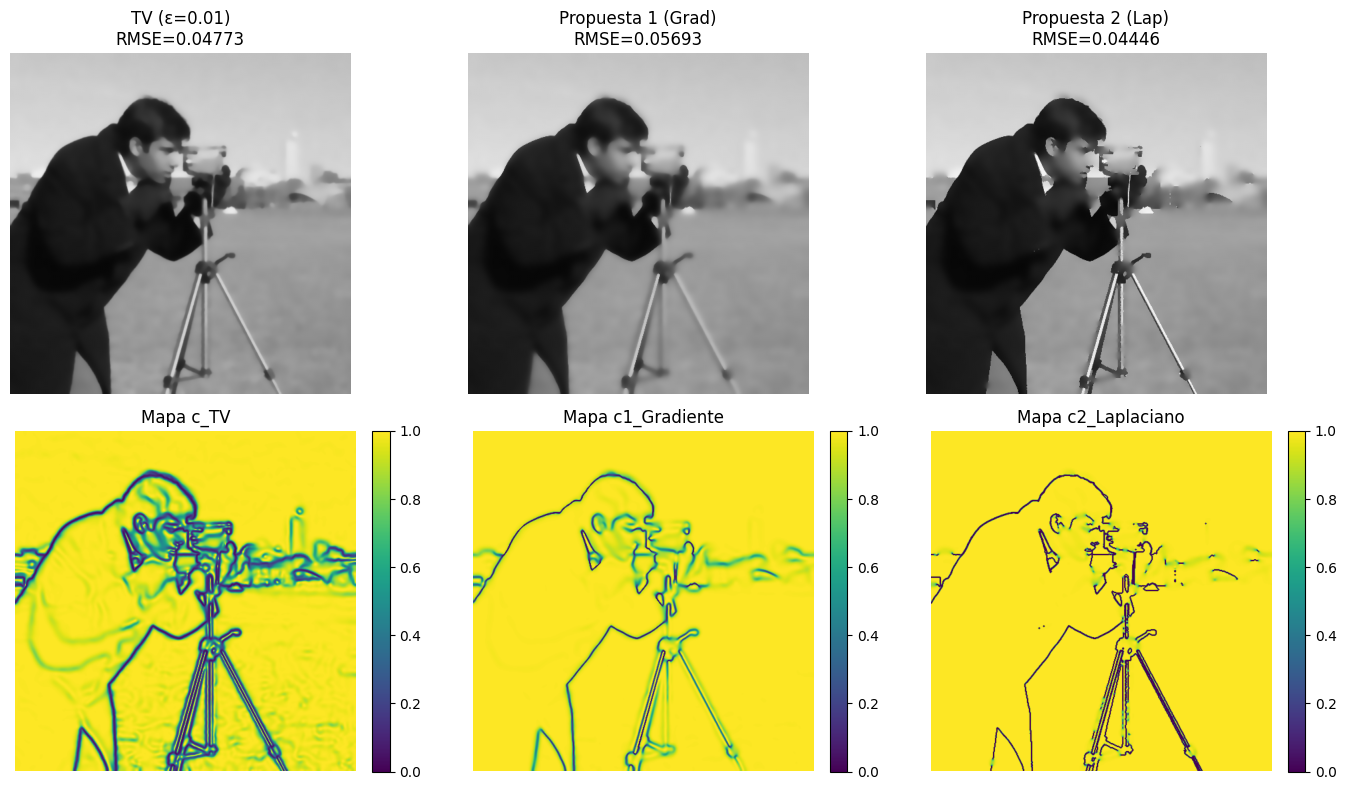

In [9]:
# Figuras comparativas de los mapas c(x,y)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(u_tv, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title(f"TV (\u03b5=0.01)\nRMSE={rmse_tv_f:.5f}")
axes[0, 0].axis('off')

axes[0, 1].imshow(u_p1, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title(f"Propuesta 1 (Grad)\nRMSE={rmse_p1_f:.5f}")
axes[0, 1].axis('off')

axes[0, 2].imshow(u_p2, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title(f"Propuesta 2 (Lap)\nRMSE={rmse_p2_f:.5f}")
axes[0, 2].axis('off')

im0 = axes[1, 0].imshow(c_tv, cmap='viridis', vmin=0, vmax=1)
axes[1, 0].set_title("Mapa c_TV")
axes[1, 0].axis('off')
fig.colorbar(im0, ax=axes[1, 0], fraction=0.046, pad=0.04)

im1 = axes[1, 1].imshow(c_p1, cmap='viridis', vmin=0, vmax=1)
axes[1, 1].set_title("Mapa c1_Gradiente")
axes[1, 1].axis('off')
fig.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04)

im2 = axes[1, 2].imshow(c_p2, cmap='viridis', vmin=0, vmax=1)
axes[1, 2].set_title("Mapa c2_Laplaciano")
axes[1, 2].axis('off')
fig.colorbar(im2, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'comparativa_difusion.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Zoom de preservación de bordes



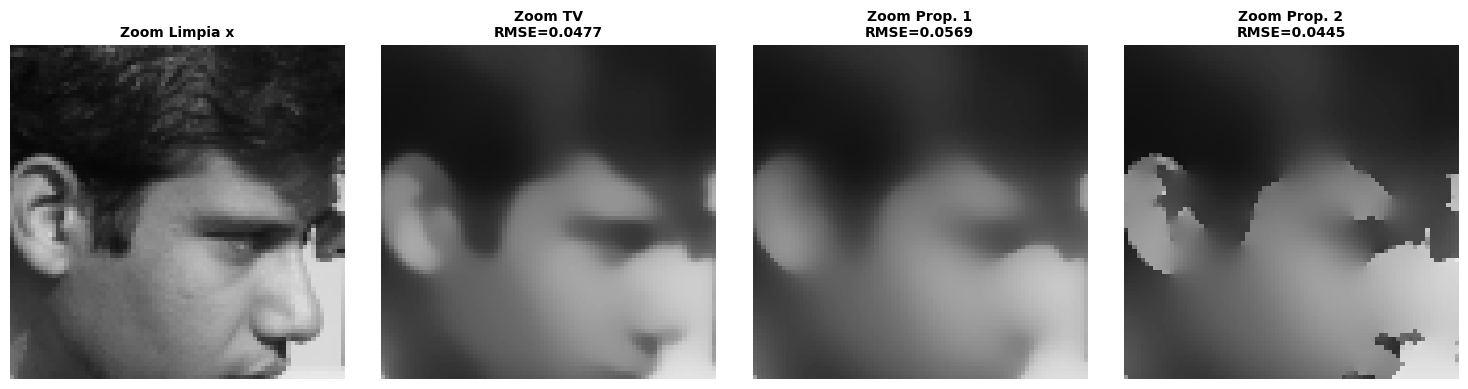

In [10]:
r1, r2, c1, c2 = 100, 180, 180, 260
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))

# Subplot 0: Imagen Limpia
axes[0].imshow(x_clean[r1:r2, c1:c2], cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Zoom Limpia x", fontsize=10, fontweight='bold')
axes[0].axis('off')

# Subplot 1: Variación Total (TV)
axes[1].imshow(u_tv[r1:r2, c1:c2], cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f"Zoom TV\nRMSE={rmse_tv_f:.4f}", fontsize=10, fontweight='bold')
axes[1].axis('off')

# Subplot 2: Propuesta 1 (Gradiente)
axes[2].imshow(u_p1[r1:r2, c1:c2], cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f"Zoom Prop. 1\nRMSE={rmse_p1_f:.4f}", fontsize=10, fontweight='bold')
axes[2].axis('off')

# Subplot 3: Propuesta 2 (Laplaciano)
axes[3].imshow(u_p2[r1:r2, c1:c2], cmap='gray', vmin=0, vmax=1)
axes[3].set_title(f"Zoom Prop. 2\nRMSE={rmse_p2_f:.4f}", fontsize=10, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'comparativa_zoom.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## Inspección puntual de pixel en borde y en zona homogenea

In [11]:
# Correr la difusión hasta la iteración k = 10 para capturar el estado real
u = y_noisy.copy()
dt = 0.20
K_g, K_l, gamma, sigma_pre = 0.05, 0.10, 0.5, 0.5
K_comb = K_g + gamma * K_l

for k in range(10):
    dN, dS, dE, dW = gradientes_4_direc(u)
    grad_sq = magnitud_gradiente_cuadrado(dN, dS, dE, dW)
    lap = laplaciano_discreto(u)
    cN, cS, cE, cW, c_map = coef_laplaciano(
        u, grad_sq, lap, dN, dS, dE, dW, 
        K_g=K_g, K_l=K_l, gamma=gamma, sigma_pre=sigma_pre
    )
    u = u + dt * (cN * dN + cS * dS + cE * dE + cW * dW)

# Estado en la iteración k = 10
dN, dS, dE, dW = gradientes_4_direc(u)
grad_sq = magnitud_gradiente_cuadrado(dN, dS, dE, dW)
grad_mag = np.sqrt(grad_sq)

u_suave = scipy.ndimage.gaussian_filter(u, sigma=sigma_pre)
lap_est = laplaciano_discreto(u_suave)
indicador_E = grad_mag + gamma * np.abs(lap_est)

cN, cS, cE, cW, c_map = coef_laplaciano(
    u, grad_sq, lap, dN, dS, dE, dW, 
    K_g=K_g, K_l=K_l, gamma=gamma, sigma_pre=sigma_pre
)

# Zona homogénea (cielo)
r_homo, c_homo = 30, 30 
# Zona de borde (contorno abrigo)
r_borde, c_borde = 130, 100

def imprimir_analisis_pixel(nombre, r, c):
    print(f"=== ANÁLISIS {nombre} en píxel ({r}, {c}) ===")
    print(f"• d_N = {dN[r,c]:.6f}, d_S = {dS[r,c]:.6f}, d_E = {dE[r,c]:.6f}, d_W = {dW[r,c]:.6f}")
    print(f"• Indicador E = {indicador_E[r,c]:.6f} (K_comb = {K_comb:.4f})")
    print(f"• Coeficientes c: c_N={cN[r,c]:.6f}, c_S={cS[r,c]:.6f}, c_E={cE[r,c]:.6f}, c_W={cW[r,c]:.6f}")
    
    delta_u = dt * (cN[r,c]*dN[r,c] + cS[r,c]*dS[r,c] + cE[r,c]*dE[r,c] + cW[r,c]*dW[r,c])
    print(f"• Actualización \u0394u = {delta_u:.6f}\n")

imprimir_analisis_pixel("PÍXEL HOMOGÉNEO", r_homo, c_homo)
imprimir_analisis_pixel("PÍXEL EN BORDE", r_borde, c_borde)

=== ANÁLISIS PÍXEL HOMOGÉNEO en píxel (30, 30) ===
• d_N = 0.000617, d_S = 0.001017, d_E = 0.002354, d_W = -0.001896
• Indicador E = 0.003001 (K_comb = 0.1000)
• Coeficientes c: c_N=0.998711, c_S=0.999240, c_E=0.999168, c_W=0.998474
• Actualización Δu = 0.000418

=== ANÁLISIS PÍXEL EN BORDE en píxel (130, 100) ===
• d_N = 0.169926, d_S = -0.485704, d_E = -0.313983, d_W = 0.167408
• Indicador E = 0.540324 (K_comb = 0.1000)
• Coeficientes c: c_N=0.020083, c_S=0.000000, c_E=0.000000, c_W=0.000000
• Actualización Δu = 0.000683



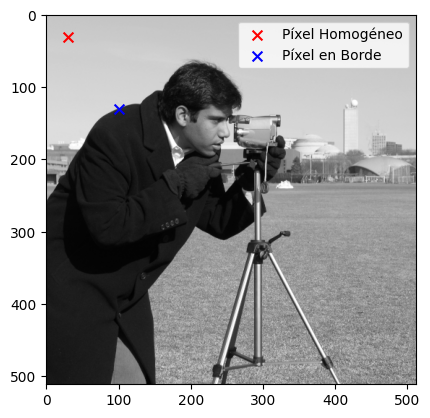

In [12]:
plt.imshow(x_clean, cmap='gray')
plt.scatter(c_homo, r_homo, c='red', s=50, marker='x', label='Píxel Homogéneo')
plt.scatter(c_borde, r_borde, c='blue', s=50, marker='x', label='Píxel en Borde')
plt.legend()
plt.show()
